In [14]:
import pandas as pd
import numpy as np
import kagglehub

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [17]:
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [18]:
insurance_data = pd.read_csv("/kaggle/input/insurance/insurance.csv")

In [19]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]


In [20]:
X = pd.get_dummies(X, columns=["region"], drop_first=True)

X["sex"] = X["sex"].map({"male": 0, "female": 1})
X["smoker"] = X["smoker"].map({"no": 0, "yes": 1})

# Feature engineering
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:

lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 20918648.889825605


MSE for alpha=0.001: 20922599.87103596
MSE for alpha=0.1: 20921803.698431376
MSE for alpha=1: 20914832.63508914
MSE for alpha=2: 20908106.779954515
MSE for alpha=5: 20890881.000633497
MSE for alpha=10: 20872844.794796683
MSE for alpha=20: 20877828.53237883
MSE for alpha=30: 20937537.133939773
MSE for alpha=40: 21046489.29389078
MSE for alpha=50: 21196929.8696089
MSE for alpha=100: 22423172.686023254


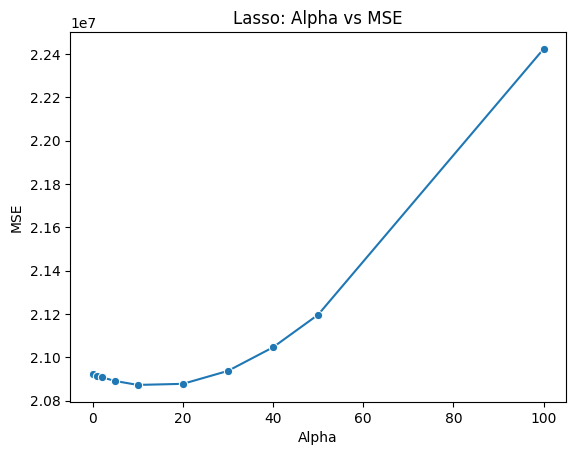

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)

    print(f"MSE for alpha={a}: {mse}")
    mses.append(mse)

# Plot
sns.lineplot(x=alphas, y=mses, marker="o")
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Lasso: Alpha vs MSE")
plt.show()

**LassoCv**

In [30]:
from sklearn.linear_model import LassoCV

a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

r2=r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)


best alpha:  0.001
MSE: 20922599.87103596
R2: 0.8652317499151699
